Tarea 05

Física Computacional

Edwin Urbina Quiroz|A76588

## Parte I: FFT

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [46]:
# Valores dados
tau = 1
t0 = 10
nu0 = 5
N = 4096 # total de puntos de muestreo en la escala temporal

In [47]:
# El rango en que la luz esta encendida es
# desde t0 - tau/2 = 10 - 1/2 = 9.5 s
# hasta t0 + tau/2 = 10 + 1/2 = 10.5 s
# Llamemosle a este rango --> rangoSenalOn

#queremos un rango de tiempo que contenga a rangoSenalOn
# tomemos 20 para que t0 sea el punto medio

T_total = 20

#ahora discretizamos el tiempo para la FFT
t = np.linspace(0, T_total, N)

#encontramos el paso
h = t[1] - t[0]

### Recuerde que para las FFTs, siempre es conveniente utilizar cierta cantidad de periodos, aún si la información es redundante. ¿A qué se debe esto? (0.25%)

Porque si el rango del tiempo es muy pequeño el pico no se ve bien definido.

### Realice un gráfico de E(t)/E0 y de Ê(ν)/E0 . Note que estos campos son complejos, realice un gráfico de ambas partes real e imaginaria. (1.0%)

In [48]:

#Contruccion de E(t)

# El problema no da un valor para la amplitud E0. Por comodidad, tomemos E0 = 1.
E0 = 1 

# Creemos un array lleno de ceros primero que servira como arreglo de estados para los E(t_i)
E = np.zeros(N, dtype=complex)

# Ahora vamos a asignar valores a E(t),  con t in rangoSenalOn
#  Definamos rangoSenalOn 
rangoSenalOn = (t >= t0 - tau/2) & (t <= t0 + tau/2) #esta construccion evita el for!!
#Ahora hacemos el relleno de E in rangoSenalOn
E[rangoSenalOn] = E0 * np.exp(-2j * np.pi * nu0 * t[rangoSenalOn]) # nos brincamos olimpicamente el foor

#Ya E(t) quedo definido como lo especifica el enunciado y listo para usarse.

In [49]:
# Contruccion de Ê(ν)
E_fft = np.fft.fft(E) # Ê(ν)
freqs = np.fft.fftfreq(N, h) # omegas

In [50]:
# Numpy grafica las frecuencias como
# [ 0, 1, 2, 3, ...  (positivas)  ...  -3, -2, -1 ]
# Es nuestro interes ordenarlas

idx = np.argsort(freqs) # indexa 
freqs_ordenadas = freqs[idx] # ordena
E_fft_ordenadas = E_fft[idx] # ordena 

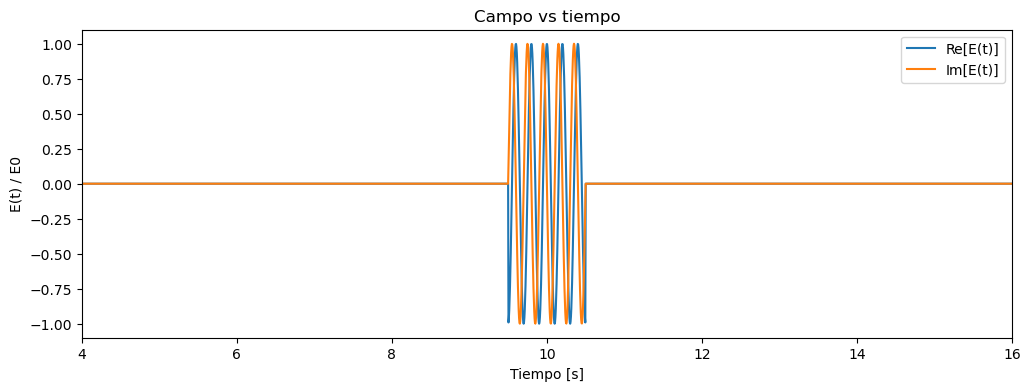

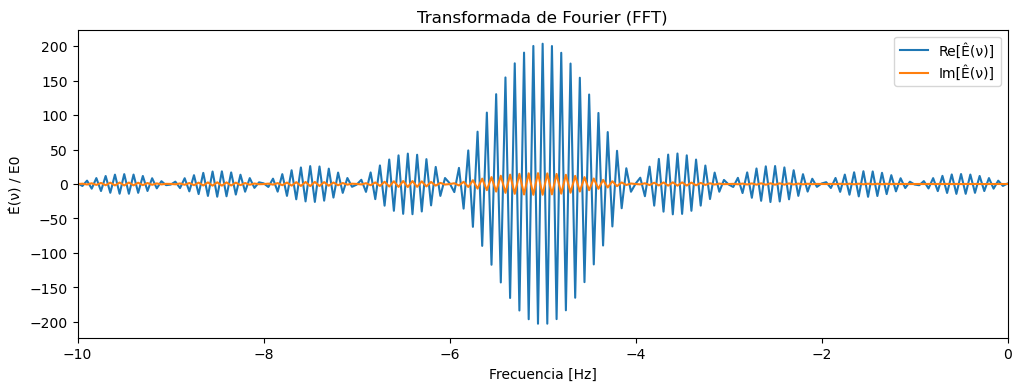

In [52]:
# Grafico de la parte real e imaginaria de E(t) vs t

plt.figure(figsize=(12,4))
plt.xlabel("Tiempo [s]")
plt.ylabel("E(t) / E0") 
plt.plot(t, E.real, label="Re[E(t)]")
plt.plot(t, E.imag, label="Im[E(t)]")
plt.xlim(4,16)  # para mejor la vision  de rangoSenalOn
plt.legend()
plt.title("Campo vs tiempo")
plt.show()

# Grafico de la parte real e imaginaria de Ê(ν) vs ν 
plt.figure(figsize=(12,4))
plt.xlabel("Frecuencia [Hz]") 
plt.ylabel("Ê(ν) / E0") 
plt.plot(freqs_ordenadas, E_fft_ordenadas.real, label="Re[Ê(ν)]") 
plt.plot(freqs_ordenadas, E_fft_ordenadas.imag, label="Im[Ê(ν)]") 
plt.xlim(-10,0) # para ver la región donde está el pico 
plt.legend()
plt.title("Transformada de Fourier (FFT)")
plt.show()

### Note que la única frecuencia del problema es ν0 . ¿Porqué el espectro de la señal, Ê(ν)/E0 , se comporta de la forma en que observa? ¿No era cierto que la transformada de Fourier “agarra” la frecuencia de las señales? Si en este caso solo hay una frecuencia, ν0 , ¿qué está pasando? (1.0%)

Esto se debe a que estamos considerando la señal solamente un tiempo limitado. Se definió la función como 

$$
E(t) =
\begin{cases}
E_0 e^{-2 i \pi \nu_0 t }, & \text{si } t_0 - \tau/2 < t < t_0 + \tau/2 \\
0, & \text{para otros casos }
\end{cases}
$$

Es decir, una función que es continua se hizo una función escalón. Entonces estamos haciendo la  FFT de $E(t)$ con información incompleta.

### Estudie la transformada de Fourier conforme τ se va haciendo más grande. ¿Qué observa? Hint: esta es una forma de visualizar el célebre principio de incertidumbre. (0.75%)

### $\tau = 2$ 

<img src="tau02.png" style="width:100%; max-width:600px;"/>

### $\tau = 4$ 

<img src="tau04.png" style="width:100%; max-width:600px;"/>

### $\tau = 8$ 

<img src="tau08.png" style="width:100%; max-width:600px;"/>

Al hacer $\tau$ más grande, le estamos pasando más información a la FFT, porque lo que ya puede refinar el espectro en el dominio de la frecuencia.

El principio de incertidumbre postula que:

$$ \Delta t \Delta \nu ≈1 $$

O sea... "si estiro uno, se encoje el otro". Y viceversa.

Si se tomara la función en $E(t)$ con $ t \in \ ]-\infty, +\infty[$ sí se vería unicamente la frecuencia $\nu$.

## Parte II: Ecuaciones Elípticas

La diferencia principal con respecto al ejercicio realizado en clase es la colocación de 2 voltajes y sus posiciones verticalese en vez de horizontales. El ejercicio trabajado en clase tenía un voltaje horizontal en la primera fila.

```python
#fila 0, todos los valores
phi[0, :] = V 
```

Ahora, tenemos 2 voltajes en posición vertical:
```python
# todas las filas comprendidas entre y1_min y y1_max, solamente la columna x1
phi[y1_min:y1_max+1, x1] = V1 
```

```python
# todas las filas comprendidas entre y2_min y y2_max, solamente la columna x2
phi[y2_min:y2_max+1, x2] = V2 
```

In [26]:
import numpy as np

# Esta función toma como argumentos el tamaño lineal de la grilla cuadrada,
# los dos voltajes y la tolerancia de convergencia
def jacobi_relaxation(M, V1, V2, tolerance):

    # Primero creamos los arreglos 2-dimensionales de la grilla
    # Vamos a necesitar dos según la regla de Jacobi
    # Note que usamos M+1, debido a que debemos contener la condición de frontera
    # phi contiene inicialmente los valores iniciales. Vamos a utilizar ceros.    
    phi = np.zeros((M + 1, M + 1), dtype=float)

    # Ahora tenemos que colocar las condiciones iniciales.
    # Recuerde accesos de listas en np.ndarray
    
    # Primer voltaje
    x1 = int(0.2 * M) #fijamos la coordenada horizontal
    y1_min = int(0.2 * M) # coordenada vertical minima
    y1_max = int(0.8 * M) # coordenada vertical maxima
    phi[y1_min:y1_max+1, x1] = V1  # llenamos el potencial. 

    # Segundo voltaje
    x2 = int(0.8 * M)
    y2_min = int(0.2 * M)
    y2_max = int(0.8 * M)
    phi[y2_min:y2_max+1, x2] = V2

    # phiprime se necesita para la iteración
    phiprime = np.zeros((M + 1, M + 1), dtype=float)

    # Iteración de Jacobi
    delta = 1.0
    its = 0

    while delta > tolerance:
        # Calculamos la iteración
        its += 1

        for i in range(M + 1):
            for j in range(M + 1):

                # Condición de frontera para voltaje 1
                if j == x1 and y1_min <= i <= y1_max:
                    phiprime[i, j] = V1
                    
                # Condición de frontera para voltaje 2
                elif j == x2 and y2_min <= i <= y2_max:
                    phiprime[i, j] = V2
                
                # Bordes externos (los dejamos en 0 V)
                elif i == 0 or i == M or j == 0 or j == M:
                    phiprime[i, j] = phi[i, j]

                # iteracion principal
                else:
                    phiprime[i, j] = 0.25 * (phi[i+1, j] + phi[i-1, j] +phi[i, j+1] + phi[i, j-1])
                    
        # Calculamos la diferencia máxima con respecto a los valores anteriores
        delta = np.max(np.abs(phi - phiprime))

        # Ahora intercambiamos los arreglos para la nueva iteración
        # El nuevo phi es el phiprime
        temp = phi
        phi = phiprime
        # El nuevo phiprime es el phi viejo
        phiprime = temp

    return phi, its


In [27]:
jacobi_vals, iterations = jacobi_relaxation(100, 1.0, -1.0, 1e-5)
print(iterations)

1818


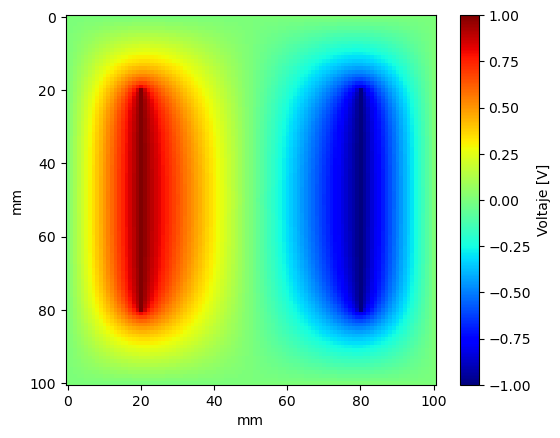

In [32]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.imshow(jacobi_vals, cmap='jet')
cbar = plt.colorbar()
cbar.set_label("Voltaje [V]")

plt.xlabel("mm")
plt.ylabel("mm")

plt.show()